In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
NU_CURRENT = 3.0   # what the model uses today
NU_FIXED   = 15.0  # proposed fix (matches empirical btc/eth)

def collect_zscores(subdir_name):
    """Return array of end-of-window z-scores for a given data subdir."""
    subdir = DATA_DIR / subdir_name
    files = sorted(subdir.glob('*.parquet'))
    zscores = []
    for f in files:
        try:
            df = pd.read_parquet(f)
            pcol = 'chainlink_price' if 'chainlink_price' in df.columns else 'chainlink_btc'
            if pcol not in df.columns:
                continue
            df = df.dropna(subset=[pcol])
            if len(df) < 10:
                continue
            prices = df[pcol].values
            ts_ms  = df['ts_ms'].values
            rets   = np.diff(np.log(prices))
            rets   = rets[np.isfinite(rets) & (rets != 0)]
            if len(rets) < 5:
                continue
            sigma_per_s  = rets.std()
            elapsed_s    = (ts_ms[-1] - ts_ms[0]) / 1000.0
            if elapsed_s < 30 or sigma_per_s <= 0:
                continue
            z = np.log(prices[-1] / prices[0]) / (sigma_per_s * np.sqrt(elapsed_s))
            if np.isfinite(z) and abs(z) < 20:
                zscores.append(z)
        except Exception:
            pass
    return np.array(zscores)

In [7]:
ASSETS = ['btc_15m', 'btc_5m', 'eth_15m', 'eth_5m', 'sol_15m', 'sol_5m', 'xrp_15m', 'xrp_5m']

data = {}
for asset in ASSETS:
    z = collect_zscores(asset)
    if len(z) >= 20:
        z_norm = (z - z.mean()) / z.std()
        nu_fit, mu_fit, sigma_fit = stats.t.fit(z_norm)
        data[asset] = dict(z=z, z_norm=z_norm, nu_fit=nu_fit,
                           kurt=stats.kurtosis(z_norm), std_raw=z.std())
        print(f'{asset:12s}: n={len(z):5d}  std_raw={z.std():.3f}  '
              f'excess_kurt={stats.kurtosis(z_norm):+.2f}  fitted_nu={nu_fit:.1f}')
    else:
        print(f'{asset:12s}: not enough data')

btc_15m     : n=  515  std_raw=0.682  excess_kurt=+0.05  fitted_nu=424.3
btc_5m      : n= 1109  std_raw=0.773  excess_kurt=+0.53  fitted_nu=22.7
eth_15m     : n=  369  std_raw=0.689  excess_kurt=+1.39  fitted_nu=12.8
eth_5m      : n=  788  std_raw=0.791  excess_kurt=+0.87  fitted_nu=15.4
sol_15m     : n=  118  std_raw=0.572  excess_kurt=-0.80  fitted_nu=852549486757.2
sol_5m      : n=  356  std_raw=0.681  excess_kurt=-0.06  fitted_nu=5175275868.3
xrp_15m     : n=  114  std_raw=0.572  excess_kurt=-1.00  fitted_nu=404731627478.6
xrp_5m      : n=  342  std_raw=0.664  excess_kurt=-0.47  fitted_nu=1165854820037.7


## Graph 1 — Current model (Student-t nu=3) vs actual data

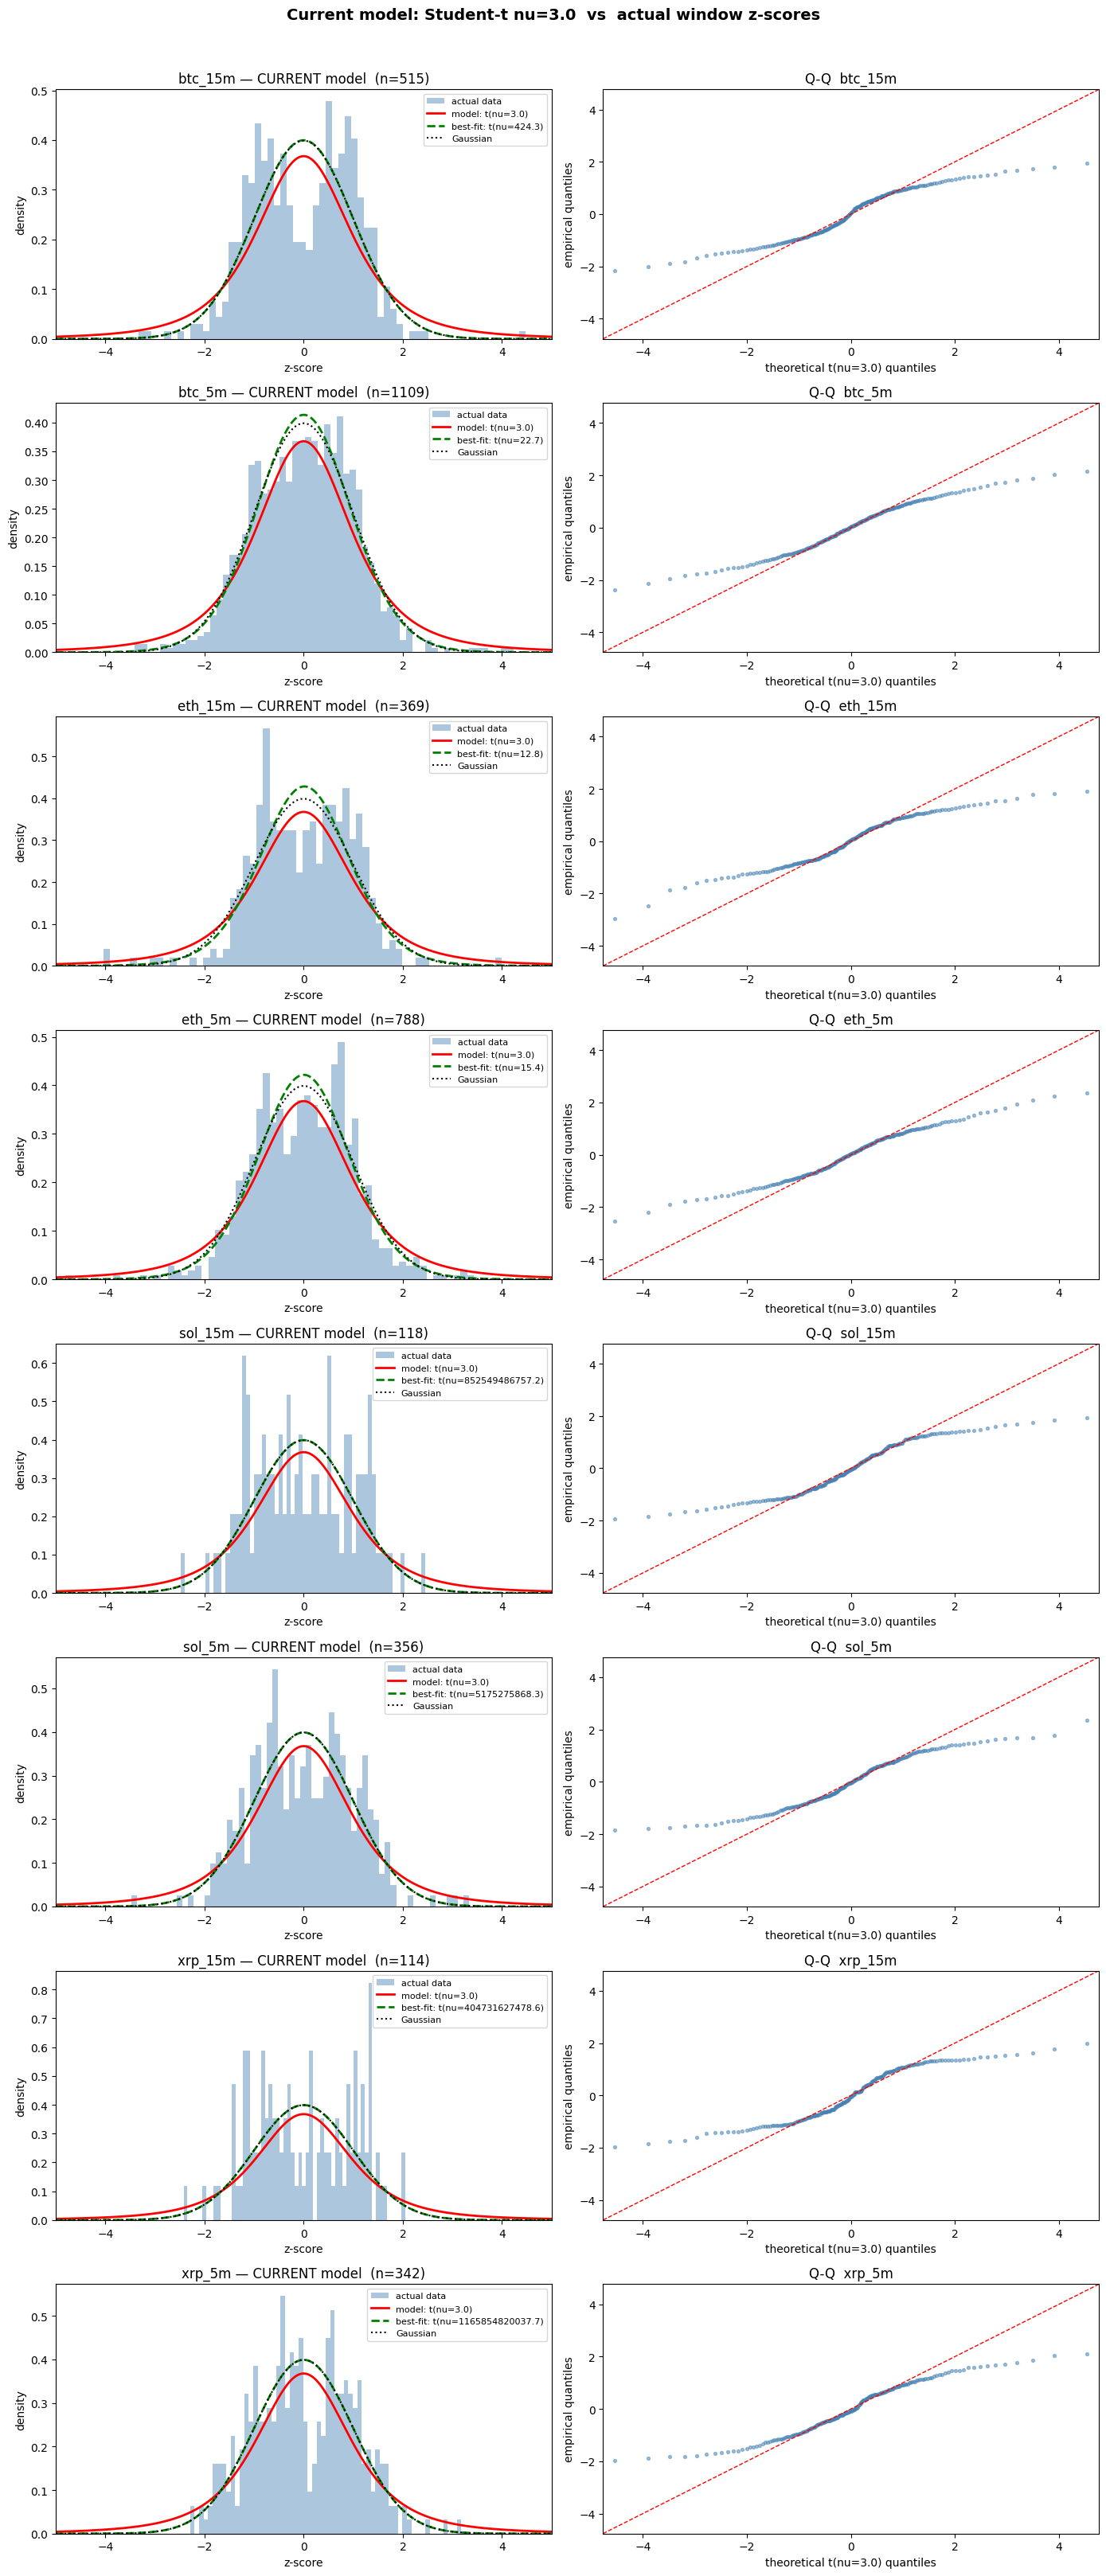

Saved dist_fit_current.png


In [3]:
def plot_fit(asset, z_norm, nu_model, title_suffix, ax_hist, ax_qq):
    x = np.linspace(-5, 5, 500)

    # empirical histogram
    ax_hist.hist(z_norm, bins=60, density=True, alpha=0.45,
                 color='steelblue', label='actual data')

    # model pdf
    pdf_model = stats.t.pdf(x, df=nu_model)
    ax_hist.plot(x, pdf_model, 'r-', lw=2,
                 label=f'model: t(nu={nu_model})')

    # fitted pdf
    nu_fit, mu_fit, s_fit = stats.t.fit(z_norm)
    pdf_fit = stats.t.pdf(x, df=nu_fit, loc=mu_fit, scale=s_fit)
    ax_hist.plot(x, pdf_fit, 'g--', lw=2,
                 label=f'best-fit: t(nu={nu_fit:.1f})')

    # Gaussian
    pdf_norm = stats.norm.pdf(x)
    ax_hist.plot(x, pdf_norm, 'k:', lw=1.5, label='Gaussian')

    ax_hist.set_xlim(-5, 5)
    ax_hist.set_xlabel('z-score')
    ax_hist.set_ylabel('density')
    ax_hist.set_title(f'{asset} — {title_suffix}  (n={len(z_norm)})')
    ax_hist.legend(fontsize=8)

    # Q-Q plot vs model distribution
    q_emp = np.percentile(z_norm, np.linspace(1, 99, 200))
    q_mod = stats.t.ppf(np.linspace(0.01, 0.99, 200), df=nu_model)
    ax_qq.scatter(q_mod, q_emp, s=8, alpha=0.5, color='steelblue')
    lim = max(abs(q_emp).max(), abs(q_mod).max()) * 1.05
    ax_qq.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax_qq.set_xlabel(f'theoretical t(nu={nu_model}) quantiles')
    ax_qq.set_ylabel('empirical quantiles')
    ax_qq.set_title(f'Q-Q  {asset}')
    ax_qq.set_xlim(-lim, lim)
    ax_qq.set_ylim(-lim, lim)

fig, axes = plt.subplots(len(data), 2, figsize=(14, 4 * len(data)))
fig.suptitle(f'Current model: Student-t nu={NU_CURRENT}  vs  actual window z-scores',
             fontsize=14, fontweight='bold', y=1.01)

for i, (asset, d) in enumerate(data.items()):
    plot_fit(asset, d['z_norm'], NU_CURRENT, 'CURRENT model',
             axes[i, 0], axes[i, 1])

plt.tight_layout()
plt.savefig('dist_fit_current.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved dist_fit_current.png')

## Graph 2 — Fixed model (Student-t nu=15) vs actual data

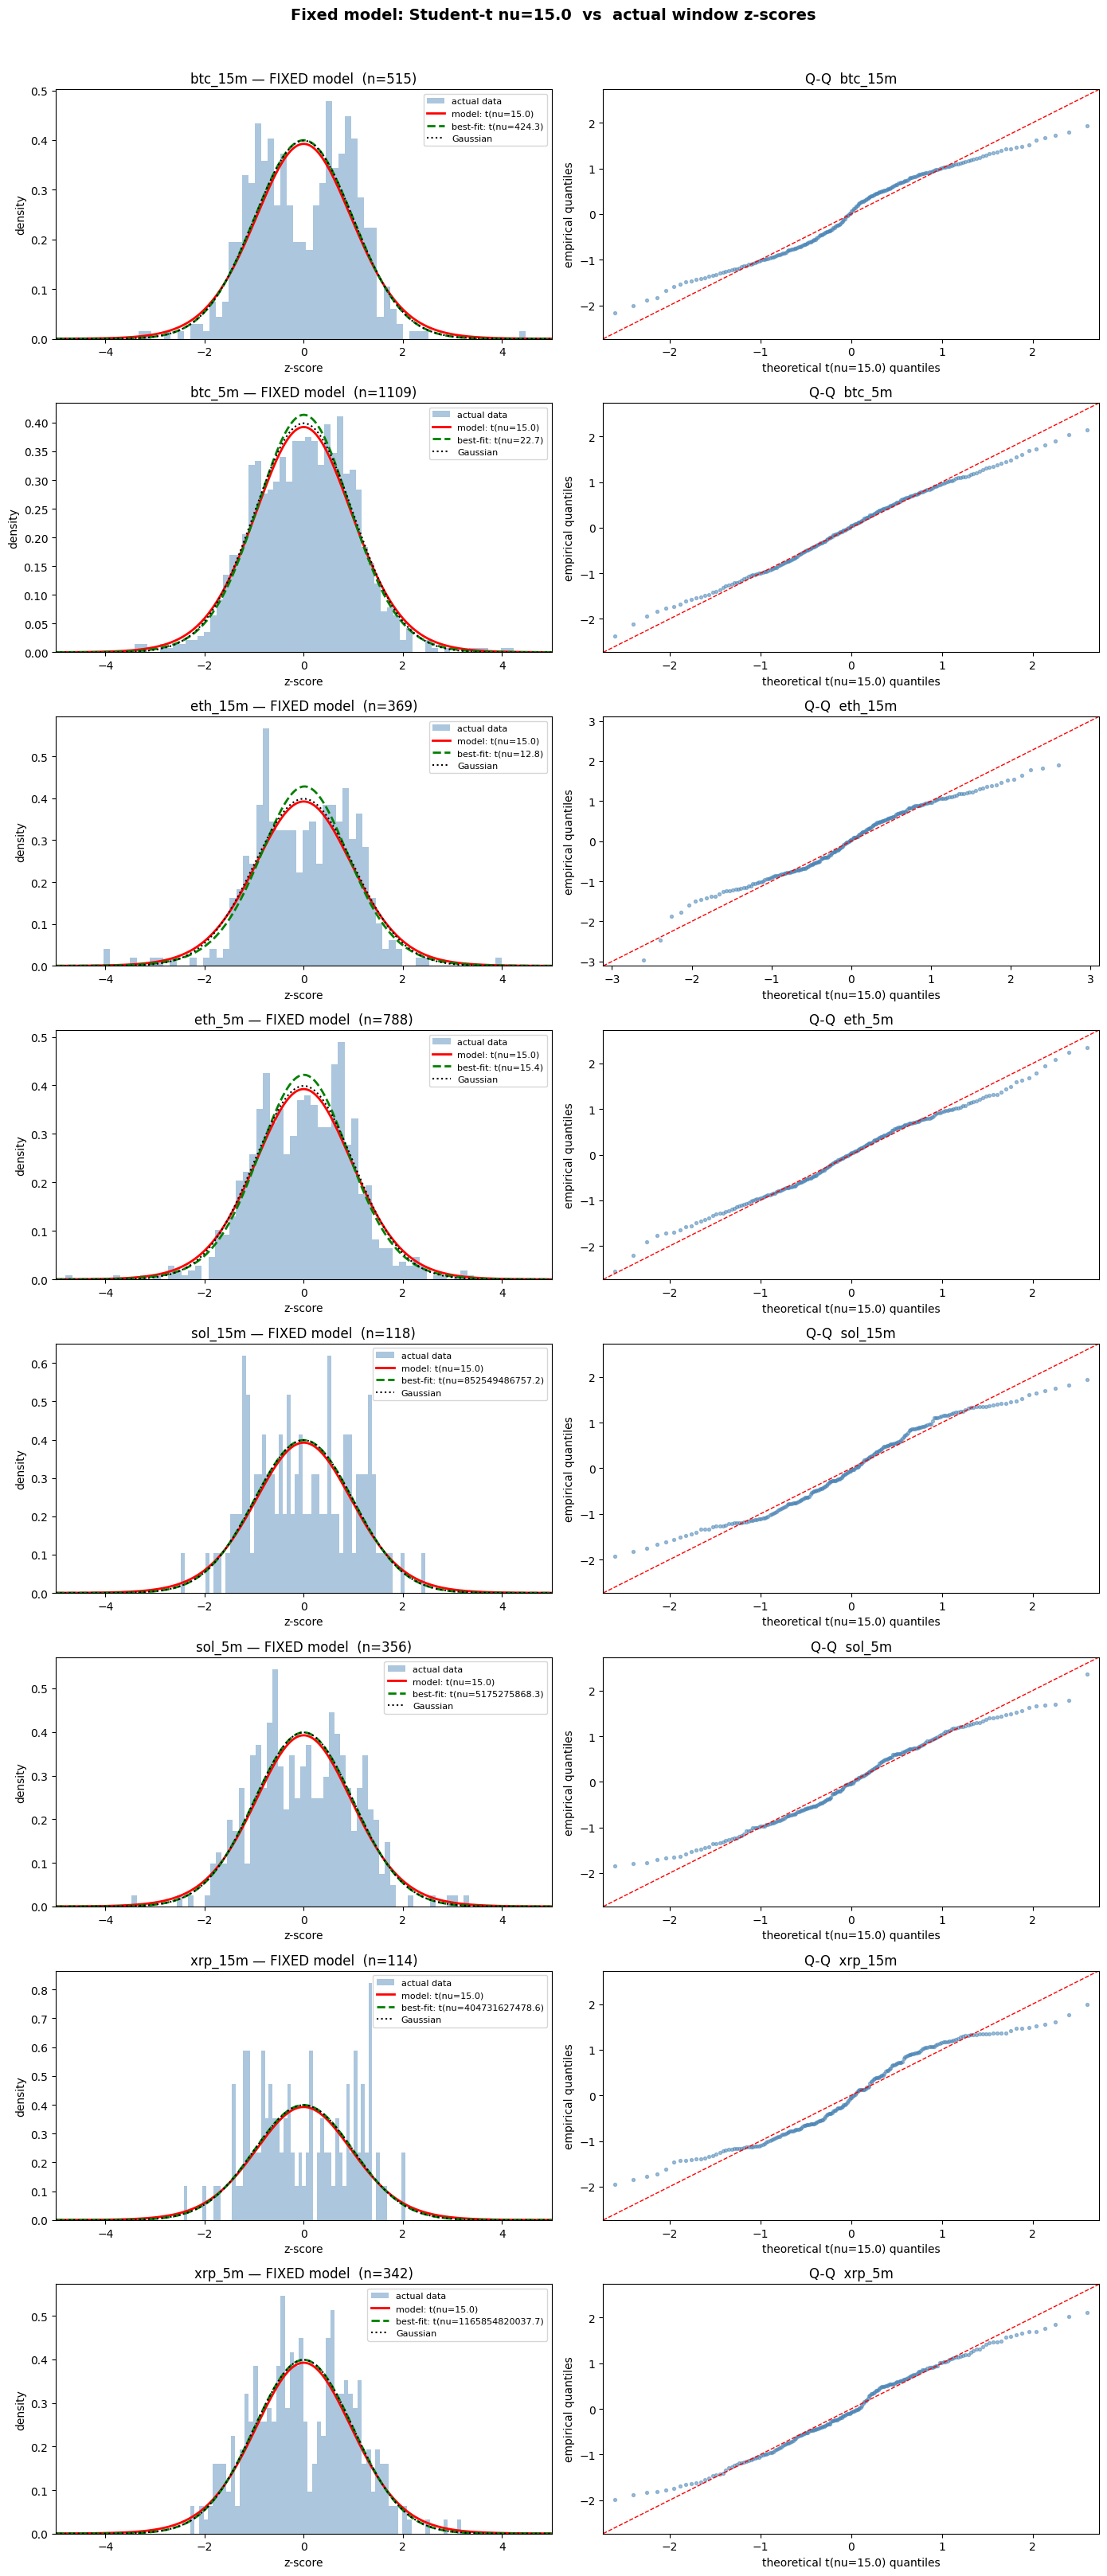

Saved dist_fit_fixed.png


In [4]:
fig, axes = plt.subplots(len(data), 2, figsize=(14, 4 * len(data)))
fig.suptitle(f'Fixed model: Student-t nu={NU_FIXED}  vs  actual window z-scores',
             fontsize=14, fontweight='bold', y=1.01)

for i, (asset, d) in enumerate(data.items()):
    plot_fit(asset, d['z_norm'], NU_FIXED, 'FIXED model',
             axes[i, 0], axes[i, 1])

plt.tight_layout()
plt.savefig('dist_fit_fixed.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved dist_fit_fixed.png')

## Graph 3 — Edge comparison: how much edge changes at each z level

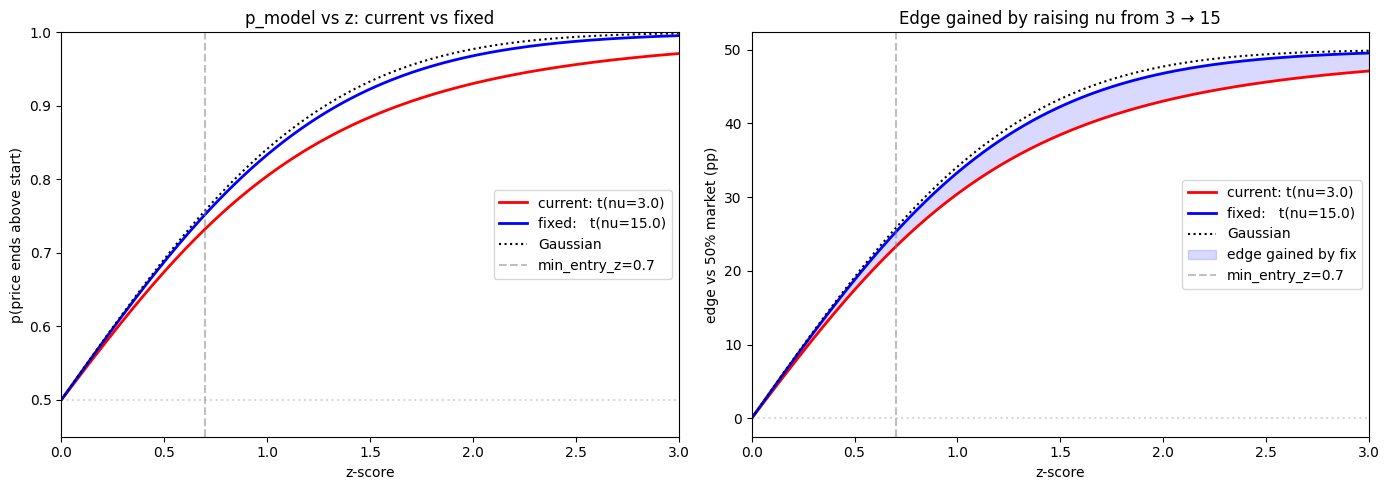

Saved dist_fit_edge_comparison.png


In [5]:
z_vals = np.linspace(0, 3, 300)

p_current = stats.t.cdf(z_vals, df=NU_CURRENT)
p_fixed   = stats.t.cdf(z_vals, df=NU_FIXED)
p_gauss   = stats.norm.cdf(z_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(z_vals, p_current, 'r-',  lw=2, label=f'current: t(nu={NU_CURRENT})')
ax1.plot(z_vals, p_fixed,   'b-',  lw=2, label=f'fixed:   t(nu={NU_FIXED})')
ax1.plot(z_vals, p_gauss,   'k:',  lw=1.5, label='Gaussian')
ax1.axvline(0.7, color='gray', linestyle='--', alpha=0.5, label='min_entry_z=0.7')
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.3)
ax1.set_xlabel('z-score')
ax1.set_ylabel('p(price ends above start)')
ax1.set_title('p_model vs z: current vs fixed')
ax1.legend()
ax1.set_xlim(0, 3)
ax1.set_ylim(0.45, 1.0)

# Edge difference
MARKET_PRICE = 0.50
edge_current = p_current - MARKET_PRICE
edge_fixed   = p_fixed   - MARKET_PRICE
edge_gauss   = p_gauss   - MARKET_PRICE

ax2.plot(z_vals, edge_current * 100, 'r-',  lw=2, label=f'current: t(nu={NU_CURRENT})')
ax2.plot(z_vals, edge_fixed   * 100, 'b-',  lw=2, label=f'fixed:   t(nu={NU_FIXED})')
ax2.plot(z_vals, edge_gauss   * 100, 'k:',  lw=1.5, label='Gaussian')
ax2.fill_between(z_vals,
                 edge_current * 100, edge_fixed * 100,
                 alpha=0.15, color='blue', label='edge gained by fix')
ax2.axvline(0.7, color='gray', linestyle='--', alpha=0.5, label='min_entry_z=0.7')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.3)
ax2.set_xlabel('z-score')
ax2.set_ylabel('edge vs 50% market (pp)')
ax2.set_title('Edge gained by raising nu from 3 → 15')
ax2.legend()
ax2.set_xlim(0, 3)

plt.tight_layout()
plt.savefig('dist_fit_edge_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved dist_fit_edge_comparison.png')